# **Libraries**

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import nltk
from nltk.stem.porter import PorterStemmer

from wordcloud import WordCloud

from textblob import TextBlob

In [5]:
plt.style.use('dark_background')

plt.rcParams.update({
    # Figure
    "figure.figsize": (10, 6),
    "figure.dpi": 120,

    # Axes
    "axes.facecolor": "#111111",
    "axes.edgecolor": "white",
    "axes.labelcolor": "white",
    "axes.titlesize": 16,
    "axes.labelsize": 12,
    "axes.grid": True,

    # Grid
    "grid.color": "#444444",
    "grid.linestyle": "--",
    "grid.linewidth": 0.6,

    # Ticks
    "xtick.color": "white",
    "ytick.color": "white",

    # Legend
    "legend.facecolor": "#111111",
    "legend.edgecolor": "white",
    "legend.fontsize": 10,

    # Lines
    "lines.linewidth": 2,
    "lines.markersize": 6,

    # Font
    "font.size": 11,
    "font.family":      "DejaVu Sans",
})

# **Loading Data**

In [6]:
df = pd.read_csv('unsent_posts.csv')

In [7]:
df.head()

,id,name,message,color,createdAt
0,19592787,evelyn,"i miss and love you so much,you’re my one, i’l...",pale-blue,2026-05-11T01:43:54.000Z
1,19592785,Emily,I really miss you today. Life isn’t the same w...,orange,2026-05-11T01:43:49.000Z
2,19592782,Donny,Hope all is well,pale-pink,2026-05-11T01:43:30.000Z
3,19592777,wyatt,"i lobe you, bub\n(purple for your fav color)",purple,2026-05-11T01:42:08.000Z
4,19592774,hailey,thank u for visiting me in my dreams. miss you...,pink,2026-05-11T01:41:48.000Z


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102017 entries, 0 to 102016
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   id         102017 non-null  int64 
 1   name       101594 non-null  object
 2   message    102017 non-null  object
 3   color      102017 non-null  object
 4   createdAt  102017 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.9+ MB


In [9]:
df.isnull().sum()

,0
id,0
name,423
message,0
color,0
createdAt,0


# **Data Preprocessing**

In [10]:
df['createdAt'] = pd.to_datetime(df['createdAt'])

df['date'] = df['createdAt'].dt.date
df['time'] = df['createdAt'].dt.time

df['date'] = pd.to_datetime(df['date'])

df.drop(columns=(['id', 'createdAt']), axis=1, inplace=True)

df = df.fillna("Unknown")

df.sort_values(by='date', inplace=True)


In [11]:
df.head()

,name,message,color,date,time
102016,Sanaa,"i’ll always love you regardless if yk that, no...",pale-pink,2025-10-09,04:10:20
101615,Lucia,I tried to be the best boyfriend but I took yo...,light-pink,2025-10-09,05:36:27
101614,Jibrail,One message doesn’t do justice to the depth of...,pale-blue,2025-10-09,05:37:07
101613,nikki,i think about you all day so i might get to se...,pink,2025-10-09,05:37:24
101612,Amit,Almost two years. I miss you most as a mentor....,black,2025-10-09,05:38:05


In [12]:
df.isnull().sum()

,0
name,0
message,0
color,0
date,0
time,0


In [13]:
print(df.duplicated().sum())

print(df[df.duplicated()])

20
             name                                            message  \
100007       Evan  If that was you, I do feel the same. We needed...   
94373    Kamalika  It's been so long right.. I wonder how you are...   
82120      Joseph  time passes, memories fade, feelings change, p...   
80677         Nic  Your pinky promises meant everything to me. I’...   
76664      sophie  I miss our spontaneous meet ups and staying ou...   
64172   valentina  Hey, are definitely the best person in my life...   
64012       Ethan  I know you’ll never love me back but I just wi...   
57352        Timi  I hope youre doing great with your new gf. I m...   
54063      Areina  i wanted to say more than just happy new year ...   
53739     cameron  starting a new year w/o the loml is hard. mayb...   
51437      Hannah  I know it's hard to be vulnerable, I understan...   
51578       Layla  You can have other friends but can you also ha...   
50589       Britt  You knew better. I miss you so much. This 

# **EDA**

## **Unique Chars**

In [32]:
"".join(sorted(set(" ".join(df['message'].astype(str)).lower())))

'\t\n !"#$%&\'()*+,-./0123456789:;<=>?@[\\]^_`abcdefghijklmnopqrstuvwxyz|~\xa0¡³´×áãäéëíïñóöøúüāğīıɞʚʻ˙˚ˬ̀́̇̈ω՞ܸ๑༏ིྀᐢᖫᖭᰔᵕ\u200b\u200c\u200d\u200e–—‘’“”„•…‧‼‿⁄\u2060₊₍₎∞≦≧⋅⑅╯╰▽◠◡☀☁☃★☆☕☘☹☺☾♀♂♠♡♥♾⚓⚡⚧⚽✈✉✋✌✝✨✩✿❀❣❤❦⬛⭐づッ㋖︎️︵︶︿﹏（）／＼＾ｉ￣𐔌𐦯𝘥𝘦𝘧𝘪𝘯𝘳🌀🌊🌌🌑🌕🌙🌟🌧🌴🌷🌸🌹🌺🌻🍀🍄🍇🍊🍍🍏🍓🍔🍚🍟🍪🍫🍰🎀🎄🎈🎵🎶🎷🎸🏉🏳🏻🏼🏽🏾🏿🐀🐇🐈🐌🐑🐒🐓🐔🐚🐜🐝🐞🐟🐠🐡🐢🐥🐧🐨🐯🐰🐱🐵🐷🐺🐻🐼🐽🐿👅👆👼👽👾💋💌💍💓💔💕💖💗💘💙💚💛💜💝💞💣💤💨💫💯📚📯🕊🕷🖤😆😇😉😊😋😒😓😔😕😖😘😙😛😝😞😢😪😭😮😳😸😺😼😽😿🙁🙂🙃🙄🙈🙏🤌🤍🤎🤓🤗🤞🤟🤠🤦🤩🤭🤰🥀🥐🥖🥜🥥🥲🥹🥺🦁🦄🦅🦆🦇🦋🦒🦕🦖🦥🦦🦧🦩🦫🦭🧁🧍🧡🧣🩵🩶🩷🩹🪲🪴🪷🪼🪿🫂🫐\U0001fae9🫰🫶'

## **Unique Users**

In [14]:
df['name'].nunique()

df['name'].value_counts().head(10)

,count
name,
Unknown,424
Alex,338
S,292
Ethan,254
Noah,235
Sam,231
J,212
Jack,209
Daniel,206


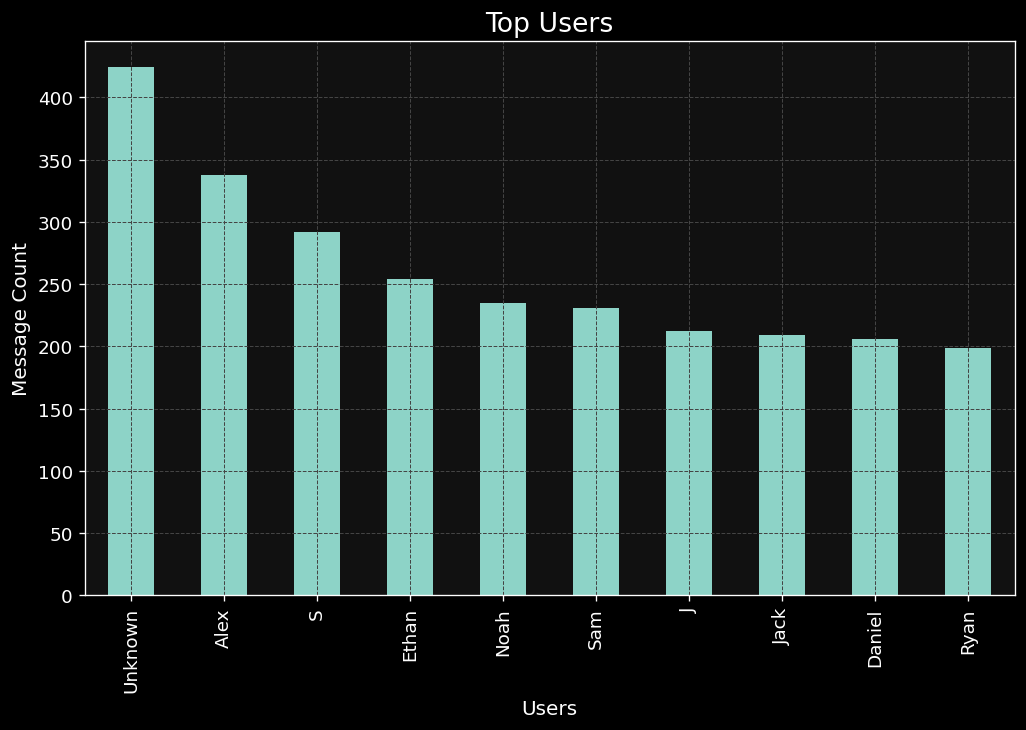

In [15]:
df['name'].value_counts().head(10).plot(kind='bar')

plt.xlabel('Users')
plt.ylabel('Message Count')
plt.title('Top Users')
plt.show()

## **Color Distribution**

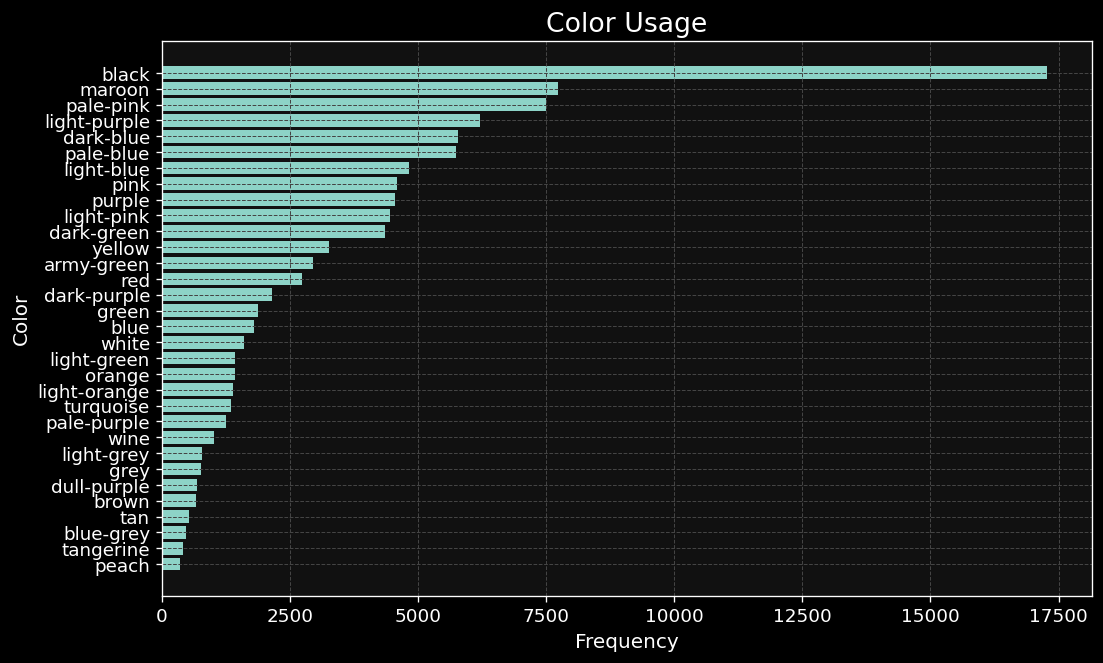

In [16]:
color_counts = df['color'].value_counts().sort_values(ascending=True)

plt.barh(color_counts.index, color_counts.values)

plt.xlabel('Frequency')
plt.ylabel('Color')
plt.title('Color Usage')

plt.show()

## **Message Length Analysis**

In [17]:
df['char_count'] = df['message'].astype(str).apply(len)

df['word_count'] = df['message'].astype(str).apply(lambda x: len(x.split()))

In [18]:
df[['char_count', 'word_count']].describe()

,char_count,word_count
count,102017.000000,102017.000000
mean,67.506533,14.409393
std,25.333793,5.402158
min,3.000000,1.000000
25%,48.000000,10.000000
50%,72.000000,15.000000
75%,90.000000,19.000000
max,100.000000,32.000000


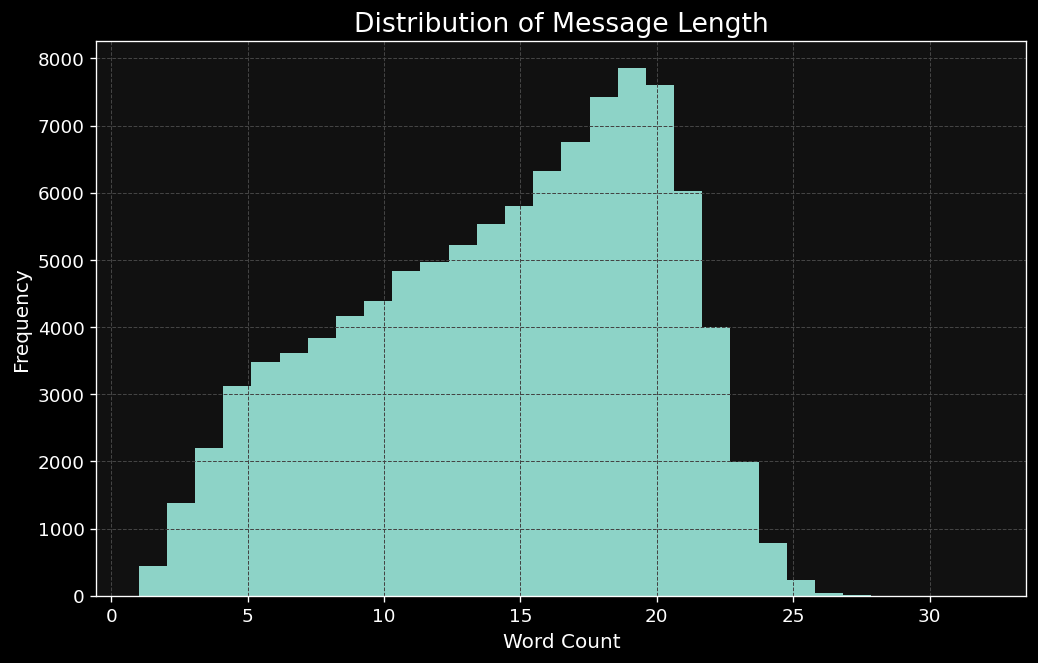

In [19]:
df['word_count'].plot(kind='hist', bins=30)

plt.xlabel('Word Count')
plt.title('Distribution of Message Length')
plt.show()

## **Most Common Words**

In [20]:
from collections import Counter

words = ' '.join(df['message'].astype(str)).lower().split()

common_words = Counter(words).most_common(20)

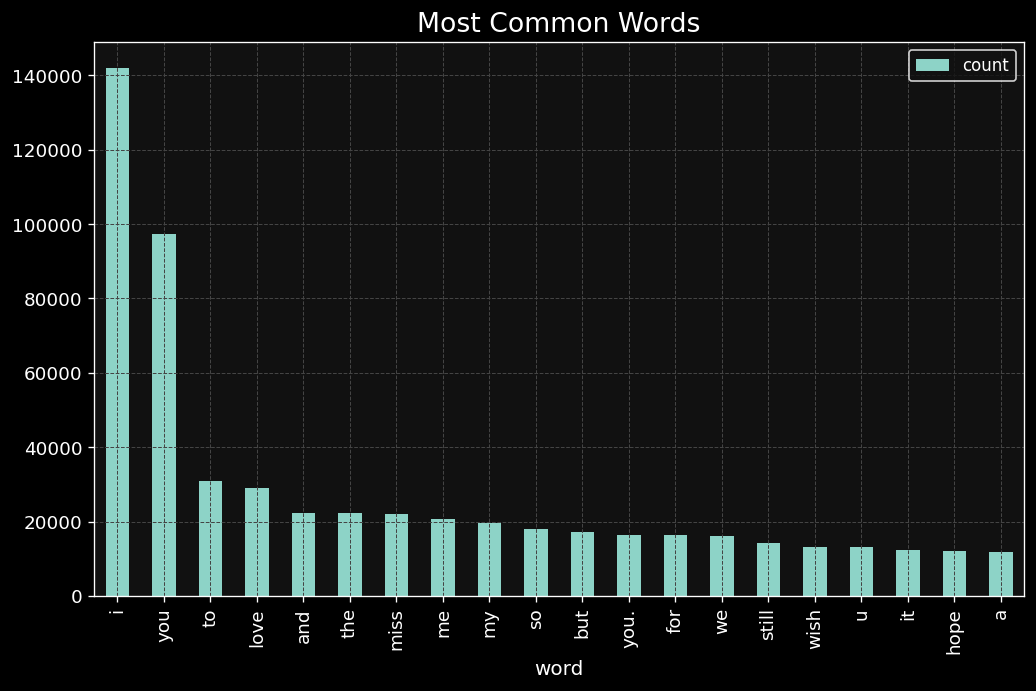

In [21]:
common_df = pd.DataFrame(common_words, columns=['word', 'count'])

common_df.plot(x='word', y='count', kind='bar')

plt.title('Most Common Words')
plt.show()

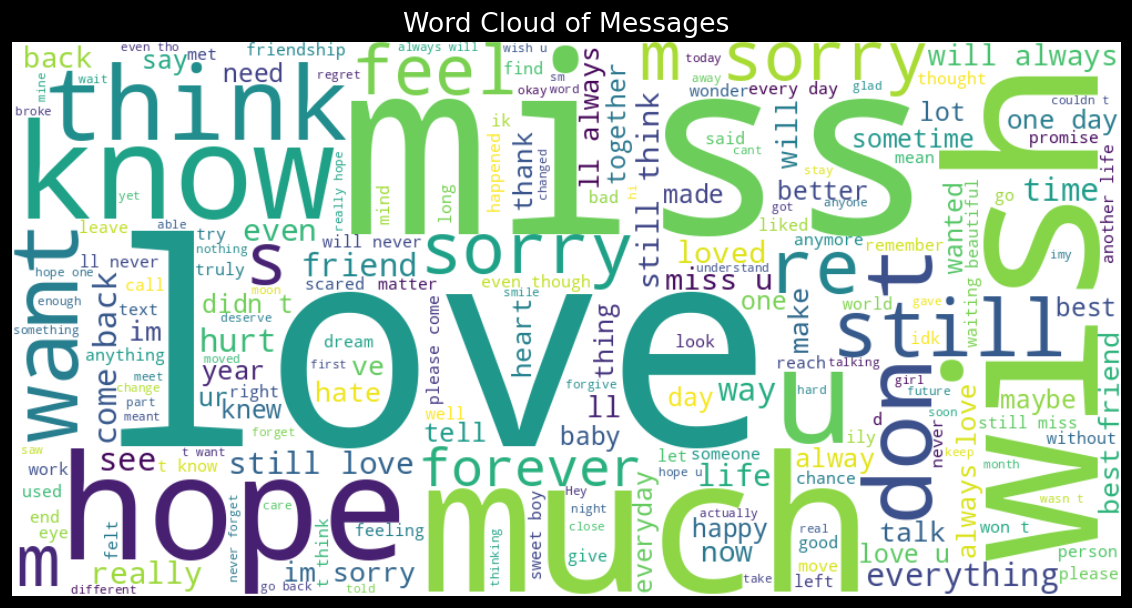

In [22]:
text = ' '.join(df['message'].astype(str))

# Generate wordcloud
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Messages')

plt.show()

## **Time-Based Analysis**

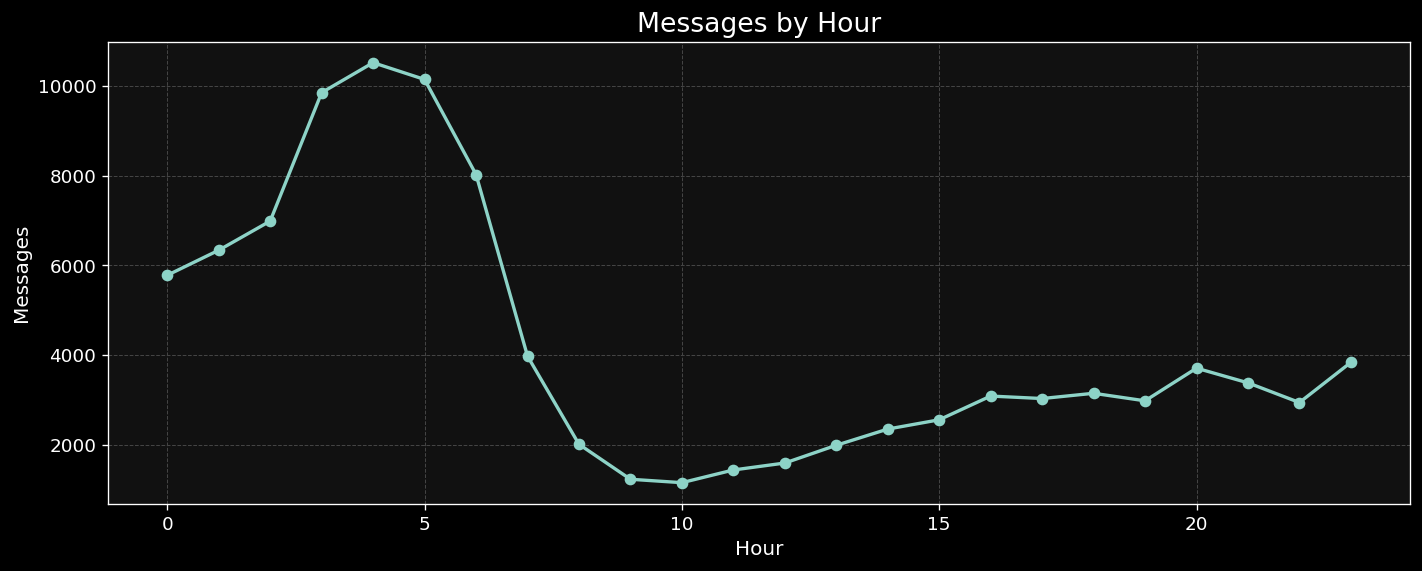

In [23]:
df['hour'] = pd.to_datetime(
    df['time'].astype(str),
    format='%H:%M:%S'
).dt.hour

df['hour'].value_counts().sort_index()

df['hour'].value_counts().sort_index().plot(kind='line', marker='o', figsize=(14, 5))

plt.xlabel('Hour')
plt.ylabel('Messages')
plt.title('Messages by Hour')
plt.show()

## **Daily Activity**

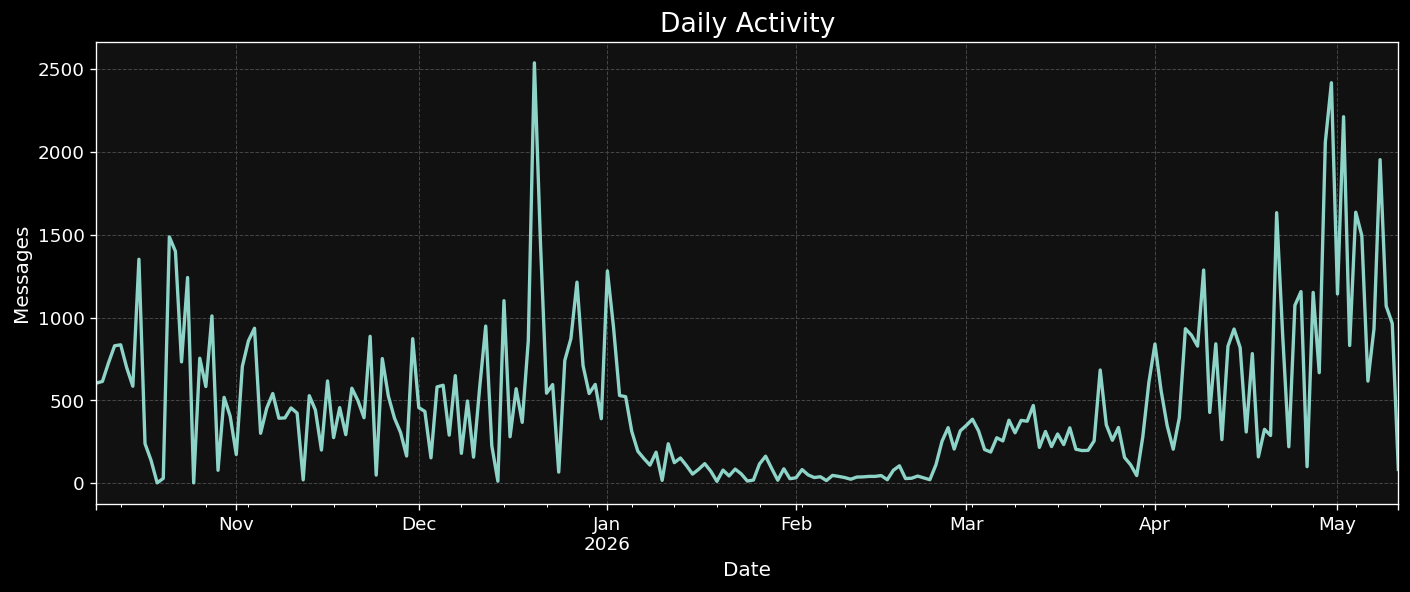

In [24]:
df['date'].value_counts().sort_index()

df['date'].value_counts().sort_index().plot(figsize=(14,5))

plt.xlabel('Date')
plt.ylabel('Messages')
plt.title('Daily Activity')
plt.show()

## **Sentiment Analysis**

In [25]:
df['sentiment'] = df['message'].astype(str).apply(
    lambda x: TextBlob(x).sentiment.polarity
)

In [26]:
df['sentiment'].describe()

,sentiment
count,102017.000000
mean,0.164143
std,0.329039
min,-1.000000
25%,0.000000
50%,0.100000
75%,0.425000
max,1.000000


Interpretation:

* Positive → > 0
* Neutral → = 0
* Negative → < 0

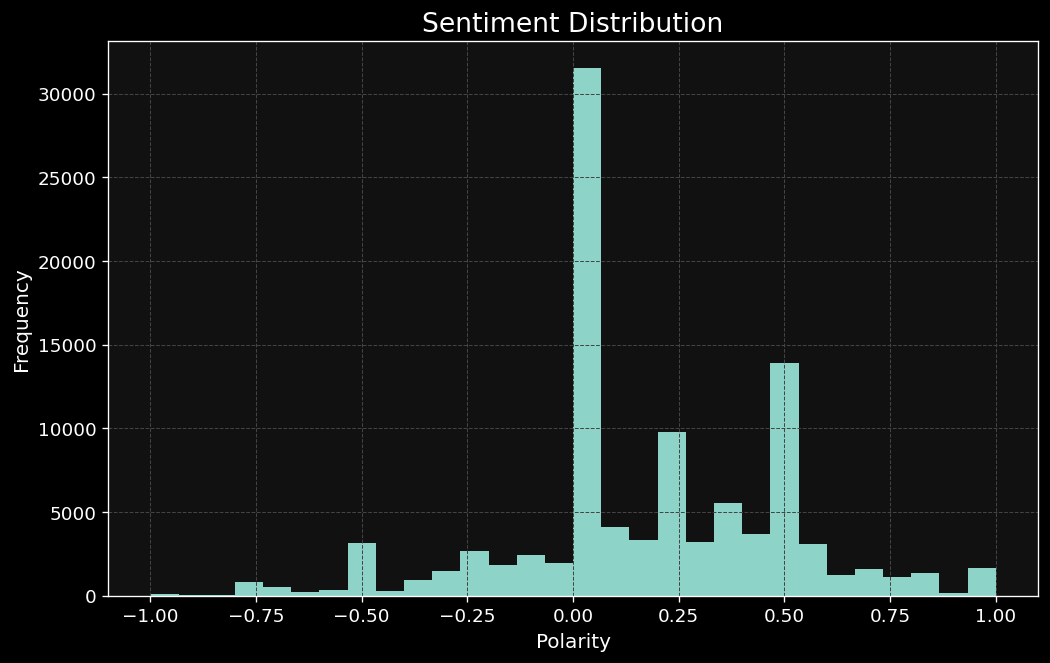

In [27]:
df['sentiment'].plot(kind='hist', bins=30)

plt.title('Sentiment Distribution')
plt.xlabel('Polarity')
plt.show()